In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

In [ ]:
df = pd.read_csv('/kaggle/input/bank-mastering/bank.csv')
    
print(f"Dataset loaded successfully.")
print(f"Shape of the dataset: {df.shape}")

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
target = 'deposit'
features_cat = [c for c in cat_cols if c != target]

# Data Analysis

In [ ]:
print("--- Dataset Structure ---")
print(df.info())
unknown_counts = (df == 'unknown').sum()
print("\n'Unknown' value counts:\n", unknown_counts[unknown_counts > 0])

In [ ]:
# 1-a) Distribution of the target variable 'deposit'

plt.figure(figsize=(6, 5))
sns.countplot(x=target, data=df, hue=target, palette='Set1', legend=False)
plt.title('Target Variable: Deposit Distribution')
plt.show()

In [ ]:
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    sns.histplot(df[col], kde=True, ax=axes[0], color='teal')
    axes[0].set_title(f'Distribution of {col}')
    
    sns.boxplot(x=df[col], ax=axes[1], color='coral')
    axes[1].set_title(f'Outliers in {col}')
    
    plt.tight_layout()
    plt.show()

In [ ]:
palettes = ['Set2', 'Paired', 'Accent', 'tab10', 'Set3', 'Pastel1', 'Pastel2', 'Dark2']
for i, col in enumerate(features_cat):
    plt.figure(figsize=(14, 6))
    sns.countplot(x=col, hue=target, data=df, palette=palettes[i % len(palettes)], 
                  order=df[col].value_counts().index)
    plt.title(f'{col.capitalize()} vs {target.capitalize()}')
    plt.xticks(rotation=45)
    plt.legend(title='Subscribed?', loc='upper right')
    plt.tight_layout()
    plt.show()

In [ ]:
plt.figure(figsize=(10, 8))
df_corr = df.copy()
df_corr[target] = df_corr[target].map({'yes': 1, 'no': 0})
correlation_matrix = df_corr.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu', fmt='.2f', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [ ]:
sns.pairplot(df.sample(1000), vars=num_cols, hue=target, palette='husl', diag_kind='kde')
plt.show()

# PreProcessing

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder

In [6]:
df['was_contacted'] = df['pdays'].apply(lambda x: 0 if x == -1 else 1)

df['deposit'] = df['deposit'].map({'yes': 1, 'no': 0})

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('deposit').tolist()

df_final = pd.get_dummies(df, columns=cat_cols, drop_first=True)

X = df_final.drop('deposit', axis=1)
y = df_final['deposit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


robust_features = ['balance', 'duration']
standard_features = [col for col in num_cols if col not in robust_features]

scaler_robust = RobustScaler()
scaler_standard = StandardScaler()

X_train[robust_features] = scaler_robust.fit_transform(X_train[robust_features])
X_train[standard_features] = scaler_standard.fit_transform(X_train[standard_features])

# Transform the test data (using parameters from train set to avoid leakage)
X_test[robust_features] = scaler_robust.transform(X_test[robust_features])
X_test[standard_features] = scaler_standard.transform(X_test[standard_features])

print("--- Preprocessing Complete ---")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print("\nFinal Features List:\n", X_train.columns.tolist())

--- Preprocessing Complete ---
Training set shape: (8929, 43)
Testing set shape: (2233, 43)

Final Features List:
 ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'was_contacted', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'education_secondary', 'education_tertiary', 'education_unknown', 'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone', 'contact_unknown', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_other', 'poutcome_success', 'poutcome_unknown']


In [7]:
def evaluate_model(model, name, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(f"\n{'='*20} {name} {'='*20}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

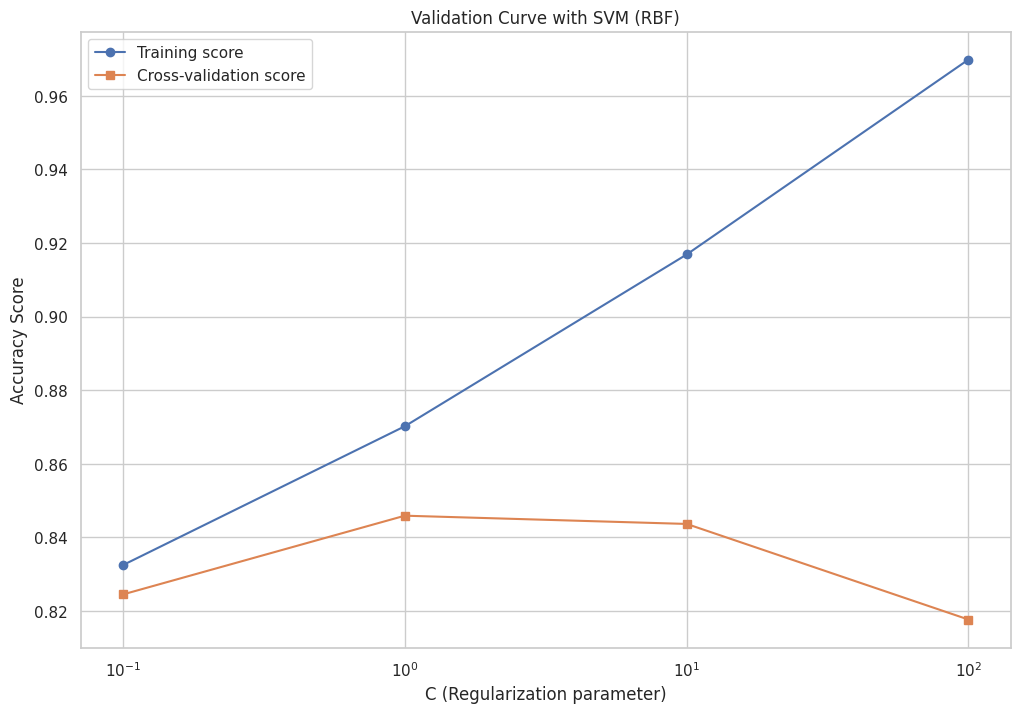

In [8]:
from sklearn.model_selection import validation_curve

param_range = [0.1, 1, 10, 100]
train_scores, test_scores = validation_curve(
    SVC(kernel='rbf', gamma='scale'), X_train, y_train, 
    param_name="C", param_range=param_range,
    cv=5, scoring="accuracy", n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(param_range, train_mean, label="Training score", marker='o')
plt.plot(param_range, test_mean, label="Cross-validation score", marker='s')
plt.xscale('log')
plt.title("Validation Curve with SVM (RBF)")
plt.xlabel("C (Regularization parameter)")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.show()

In [9]:
svm_kernels = {
    'linear': {'C': [0.1, 1, 10]},
    'poly': {'C': [1, 10], 'degree': [2, 3]},
    'rbf': {'C': [1, 10], 'gamma': ['scale', 0.1]}
}

for kernel, params in svm_kernels.items():
    print(f"Tuning SVM - Kernel: {kernel}...")
    svc = SVC(kernel=kernel, probability=True, random_state=42)
    grid = GridSearchCV(svc, params, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    evaluate_model(grid.best_estimator_, f"SVM ({kernel})", X_test, y_test)

Tuning SVM - Kernel: linear...

==================== SVM (linear) ====================
Accuracy: 0.8307
ROC-AUC: 0.9073

Confusion Matrix:
[[988 187]
 [191 867]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1175
           1       0.82      0.82      0.82      1058

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233

Tuning SVM - Kernel: poly...

==================== SVM (poly) ====================
Accuracy: 0.8540
ROC-AUC: 0.9217

Confusion Matrix:
[[980 195]
 [131 927]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.83      0.86      1175
           1       0.83      0.88      0.85      1058

    accuracy                           0.85      2233
   macro avg       0.85      0.86      0.85      2233
weighted avg       0.86      0.85

# Random Forest

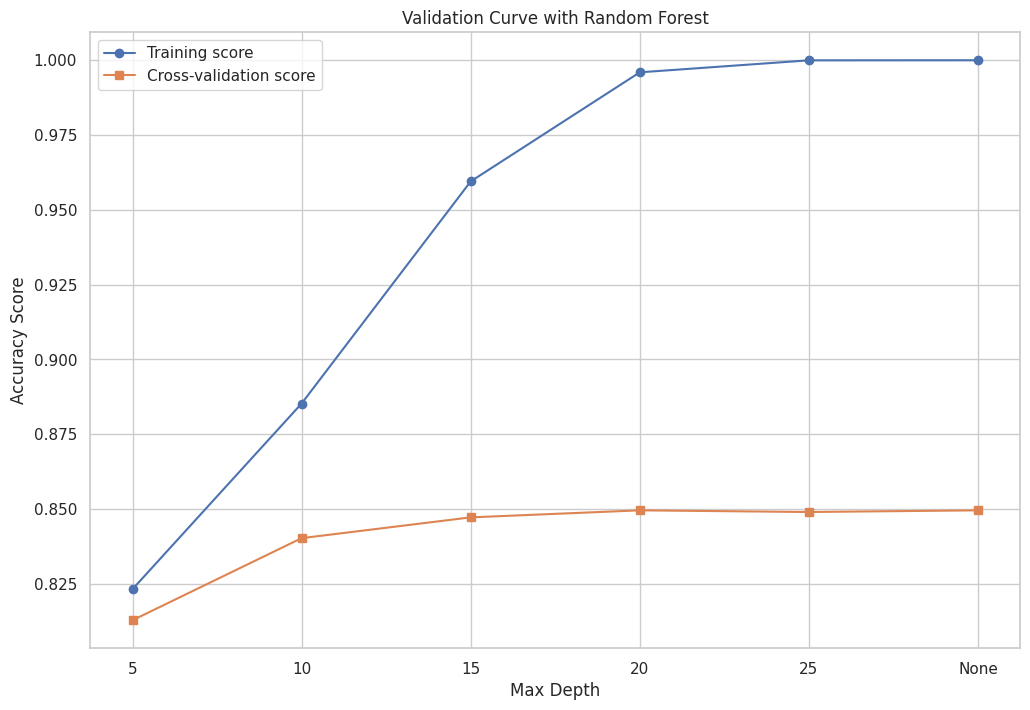

In [10]:
depth_range = [5, 10, 15, 20, 25, None]
depth_labels = [str(d) for d in depth_range]

train_scores, test_scores = validation_curve(
    RandomForestClassifier(n_estimators=100, random_state=42), X_train, y_train, 
    param_name="max_depth", param_range=depth_range,
    cv=5, scoring="accuracy", n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(depth_labels, train_mean, label="Training score", marker='o')
plt.plot(depth_labels, test_mean, label="Cross-validation score", marker='s')
plt.title("Validation Curve with Random Forest")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.show()

In [11]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 15],
    'min_samples_split': [2, 5]
}
print("\nTuning Random Forest...")
rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)
evaluate_model(rf_grid.best_estimator_, "Random Forest", X_test, y_test)


Tuning Random Forest...

==================== Random Forest ====================
Accuracy: 0.8580
ROC-AUC: 0.9214

Confusion Matrix:
[[968 207]
 [110 948]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.82      0.86      1175
           1       0.82      0.90      0.86      1058

    accuracy                           0.86      2233
   macro avg       0.86      0.86      0.86      2233
weighted avg       0.86      0.86      0.86      2233



# Gradient Boost

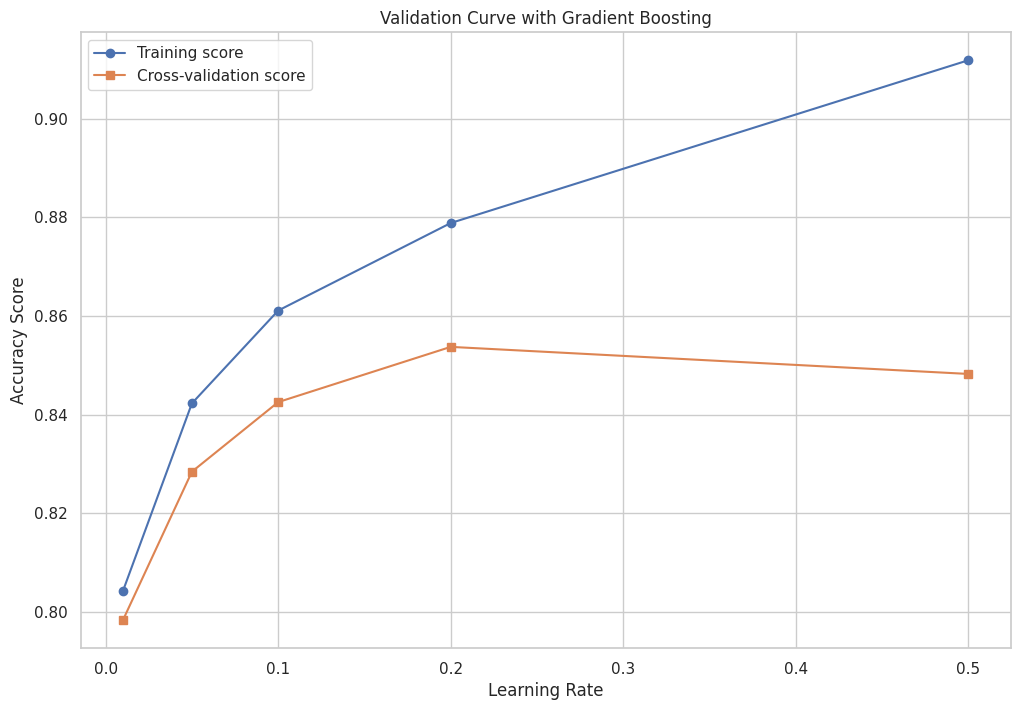

In [12]:
lr_range = [0.01, 0.05, 0.1, 0.2, 0.5]
train_scores, test_scores = validation_curve(
    GradientBoostingClassifier(n_estimators=100, random_state=42), X_train, y_train, 
    param_name="learning_rate", param_range=lr_range,
    cv=5, scoring="accuracy", n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(lr_range, train_mean, label="Training score", marker='o')
plt.plot(lr_range, test_mean, label="Cross-validation score", marker='s')
plt.title("Validation Curve with Gradient Boosting")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.show()

In [13]:
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}
print("\nTuning Gradient Boosting...")
gb = GradientBoostingClassifier(random_state=42)
gb_grid = GridSearchCV(gb, gb_params, cv=5, scoring='accuracy', n_jobs=-1)
gb_grid.fit(X_train, y_train)
evaluate_model(gb_grid.best_estimator_, "Gradient Boosting", X_test, y_test)


Tuning Gradient Boosting...

==================== Gradient Boosting ====================
Accuracy: 0.8665
ROC-AUC: 0.9285

Confusion Matrix:
[[996 179]
 [119 939]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87      1175
           1       0.84      0.89      0.86      1058

    accuracy                           0.87      2233
   macro avg       0.87      0.87      0.87      2233
weighted avg       0.87      0.87      0.87      2233




--- Final Comparison Table ---
               Model  Accuracy  F1-Score  \
0         SVM-Linear  0.830721  0.821023   
1            SVM-RBF  0.854008  0.851413   
2           SVM-Poly  0.847738  0.843606   
3      Random Forest  0.858039  0.856756   
4  Gradient Boosting  0.866995  0.863574   

                                         Best Params  
0                                          {'C': 10}  
1                             {'C': 1, 'gamma': 0.1}  
2                              {'C': 1, 'degree': 2}  
3  {'max_depth': None, 'min_samples_split': 5, 'n...  
4  {'learning_rate': 0.2, 'max_depth': 5, 'n_esti...  


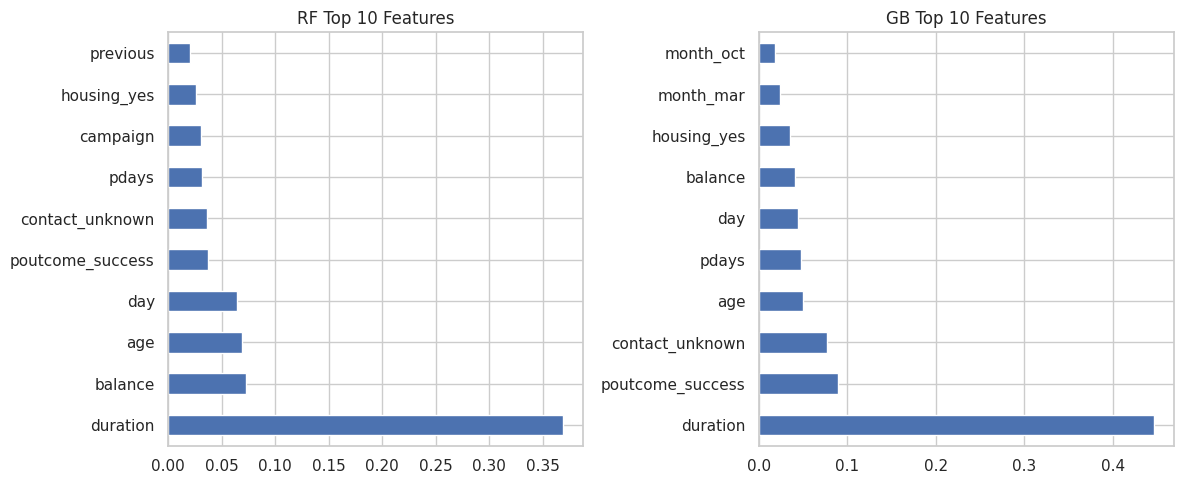

In [15]:
# Display Final Table
results_df = pd.DataFrame(final_results)
print("\n--- Final Comparison Table ---")
print(results_df[['Model', 'Accuracy', 'F1-Score', 'Best Params']])

# --- Feature Importance Visualization (For RF and GB) ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
feat_importances_rf = pd.Series(best_models['Random Forest'].feature_importances_, index=X_train.columns)
feat_importances_rf.nlargest(10).plot(kind='barh', title='RF Top 10 Features')

plt.subplot(1, 2, 2)
feat_importances_gb = pd.Series(best_models['Gradient Boosting'].feature_importances_, index=X_train.columns)
feat_importances_gb.nlargest(10).plot(kind='barh', title='GB Top 10 Features')
plt.tight_layout()
plt.show()

In [16]:
X_final_no_duration = X.drop('duration', axis=1)

X_train_nd, X_test_nd, y_train_nd, y_test_nd = train_test_split(
    X_final_no_duration, y, test_size=0.3, random_state=42, stratify=y
)

models_to_test = {
    'SVM-RBF': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.2, max_depth=5, random_state=42)
}

final_nd_results = []

for name, model in models_to_test.items():
    model.fit(X_train_nd, y_train_nd)
    y_pred = model.predict(X_test_nd)
    
    final_nd_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_nd, y_pred),
        'F1-Score': f1_score(y_test_nd, y_pred),
        'Recall': recall_score(y_test_nd, y_pred)
    })

nd_results_df = pd.DataFrame(final_nd_results)
print("--- Final Comparison WITHOUT Duration (Realistic Scenario) ---")
print(nd_results_df)

--- Final Comparison WITHOUT Duration (Realistic Scenario) ---
               Model  Accuracy  F1-Score    Recall
0            SVM-RBF  0.571215  0.464978  0.393195
1      Random Forest  0.725590  0.682994  0.623819
2  Gradient Boosting  0.721111  0.684885  0.639572


Generating Confusion Matrices WITH Duration...


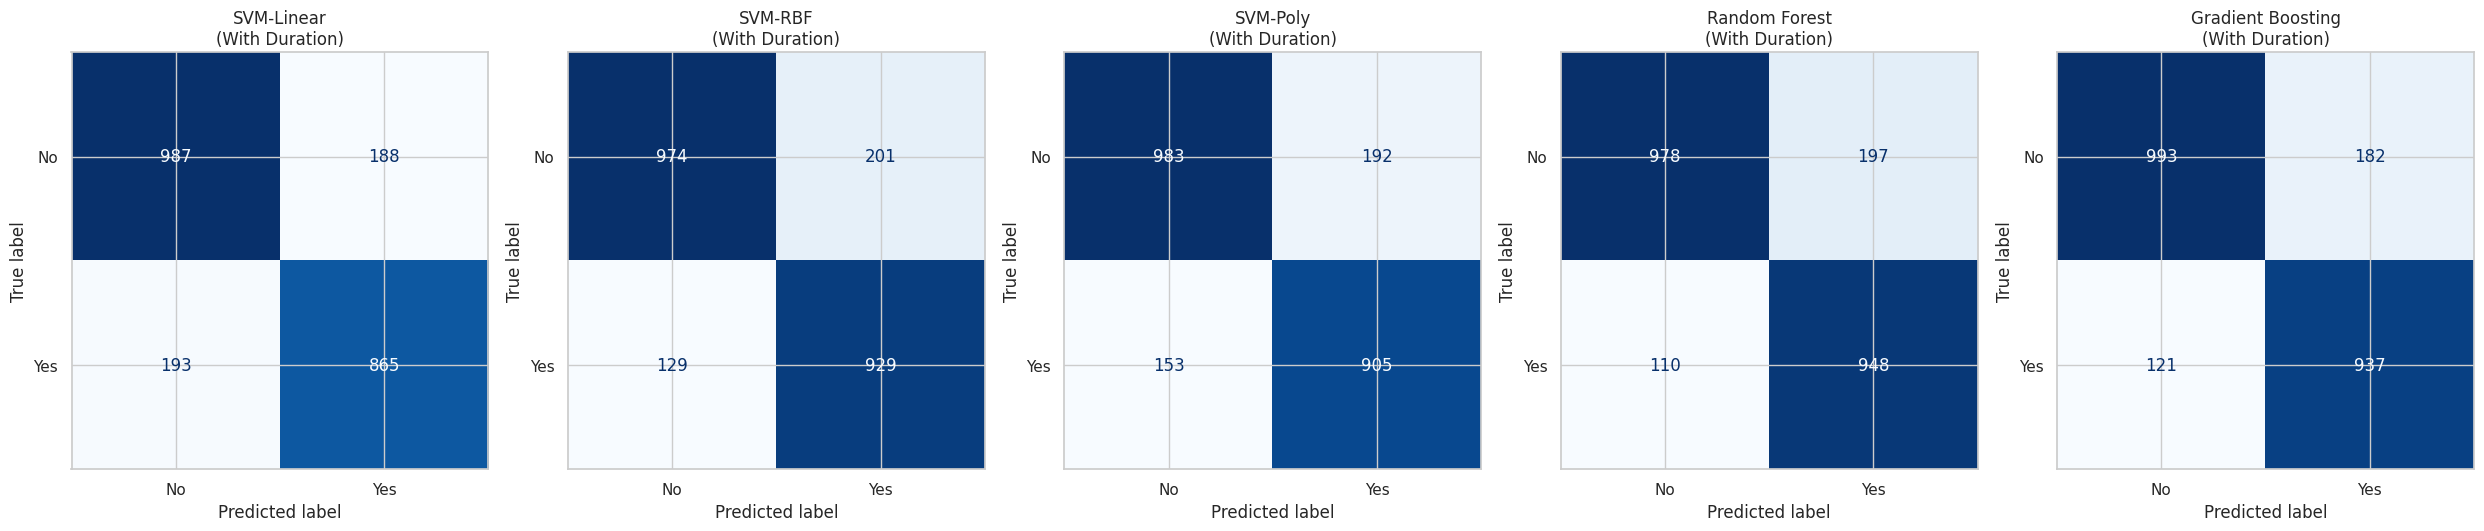

Generating Confusion Matrices WITHOUT Duration...


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    'SVM-Linear': SVC(kernel='linear', C=0.1, random_state=42),
    'SVM-RBF': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    'SVM-Poly': SVC(kernel='poly', C=1.0, degree=3, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.2, max_depth=5, random_state=42)
}

def plot_all_confusion_matrices(X_train_data, X_test_data, y_train_data, y_test_data, title_suffix):
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    for i, (name, model) in enumerate(models.items()):
        model.fit(X_train_data, y_train_data)
        y_pred = model.predict(X_test_data)
        cm = confusion_matrix(y_test_data, y_pred)
        
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
        disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
        axes[i].set_title(f"{name}\n({title_suffix})")
    plt.tight_layout()
    plt.show()

print("Generating Confusion Matrices WITH Duration...")
plot_all_confusion_matrices(X_train, X_test, y_train, y_test, "With Duration")

print("Generating Confusion Matrices WITHOUT Duration...")
plot_all_confusion_matrices(X_train_nd, X_test_nd, y_train_nd, y_test_nd, "No Duration")